In [ ]:
# ============================================================
# VARIATIONIST FREQUENCY ANALYSIS
# Ablative Absolute vs CUM + Subjunctive
# ============================================================

# CELLA 1 — Installa e importa le librerie necessarie
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print("Dataset caricato correttamente.")
print(f"Righe: {len(df)}, Colonne: {list(df.columns)}")
print(f"\nDistribuzione costruzioni:\n{df['construction'].value_counts()}")
print(f"\nDistribuzione autori:\n{df['Author'].value_counts()}")

Saving DATA SET DEFINITIVO.xlsx to DATA SET DEFINITIVO.xlsx
Dataset caricato correttamente.
Righe: 160, Colonne: ['sentence', 'work', 'construction', 'Author', 'Position ', 'information Status', 'Topic persistence', 'Discourse Hierarchy', 'Agentivity']

Distribuzione costruzioni:
construction
AA     89
CUM    71
Name: count, dtype: int64

Distribuzione autori:
Author
Cesare       99
Cicerone     38
Sallustio    23
Name: count, dtype: int64


In [ ]:
from scipy.stats import chi2_contingency

def analisi_variabile(df, variabile, titolo=None):
    if titolo is None:
        titolo = variabile

    print(f"\n{'='*60}")
    print(f"VARIABILE: {titolo}")
    print(f"{'='*60}")

    ct = pd.crosstab(df[variabile], df['construction'],
                     margins=True, margins_name='TOTALE')

    ct_pct = pd.crosstab(df[variabile], df['construction'],
                          normalize='index').round(3) * 100
    ct_pct.columns = [f'{c} %' for c in ct_pct.columns]

    print("\nFrequenze osservate:")
    print(ct)
    print("\nPercentuali per riga:")
    print(ct_pct)

    ct_raw = pd.crosstab(df[variabile], df['construction'])
    chi2, p, dof, expected = chi2_contingency(ct_raw)

    print(f"\nChi-quadro: {chi2:.4f}")
    print(f"Gradi di liberta: {dof}")
    print(f"p-value: {p:.4f}", end=" ")
    if p < 0.001:
        print("***")
    elif p < 0.01:
        print("**")
    elif p < 0.05:
        print("*")
    else:
        print("(non significativo)")

    print("\nFrequenze attese:")
    expected_df = pd.DataFrame(expected,
                                index=ct_raw.index,
                                columns=ct_raw.columns).round(2)
    print(expected_df)

    return chi2, p, dof

In [ ]:
print("\n" + "="*60)
print("ANALISI SUL CAMPIONE COMPLETO (N=160)")
print("="*60)

variabili = {
    'Position ': 'Position (0=interna, 1=apertura paragrafo)',
    'information Status': 'Information Status (new / recap / anchored)',
    'Topic persistence': 'Topic Persistence (setting / continuous / discontinuous)',
    'Discourse Hierarchy': 'Discourse Hierarchy (A / B)',
    'Agentivity': 'Agentivity (C / D)'
}

risultati_globali = {}
for var, titolo in variabili.items():
    chi2, p, dof = analisi_variabile(df, var, titolo)
    risultati_globali[var] = {'chi2': chi2, 'p': p, 'dof': dof}



ANALISI SUL CAMPIONE COMPLETO (N=160)

VARIABILE: Position (0=interna, 1=apertura paragrafo)

Frequenze osservate:
construction  AA  CUM  TOTALE
Position                     
0             71   63     134
1             18    8      26
TOTALE        89   71     160

Percentuali per riga:
           AA %  CUM %
Position              
0          53.0   47.0
1          69.2   30.8

Chi-quadro: 1.7166
Gradi di liberta: 1
p-value: 0.1901 (non significativo)

Frequenze attese:
construction     AA    CUM
Position                  
0             74.54  59.46
1             14.46  11.54

VARIABILE: Information Status (new / recap / anchored)

Frequenze osservate:
construction        AA  CUM  TOTALE
information Status                 
anchored             2   65      67
new                 54    5      59
recap               33    1      34
TOTALE              89   71     160

Percentuali per riga:
                    AA %  CUM %
information Status             
anchored             3.0   97.0
new

In [ ]:
print("\n" + "="*60)
print("RIEPILOGO RISULTATI — CAMPIONE COMPLETO")
print("="*60)
print(f"{'Variabile':<35} {'Chi2':>8} {'df':>4} {'p-value':>10} {'Sig.':>6}")
print("-"*65)
for var, res in risultati_globali.items():
    sig = '***' if res['p'] < 0.001 else '**' if res['p'] < 0.01 else '*' if res['p'] < 0.05 else 'n.s.'
    print(f"{var:<35} {res['chi2']:>8.4f} {res['dof']:>4} {res['p']:>10.4f} {sig:>6}")



RIEPILOGO RISULTATI — CAMPIONE COMPLETO
Variabile                               Chi2   df    p-value   Sig.
-----------------------------------------------------------------
Position                              1.7166    1     0.1901   n.s.
information Status                  129.6675    2     0.0000    ***
Topic persistence                   114.9459    2     0.0000    ***
Discourse Hierarchy                  98.7563    1     0.0000    ***
Agentivity                           96.1645    1     0.0000    ***


In [ ]:
for autore in df['Author'].unique():
    df_autore = df[df['Author'] == autore]
    print(f"\n\n{'#'*60}")
    print(f"ANALISI PER AUTORE: {autore.upper()} (N={len(df_autore)})")
    print(f"Distribuzione costruzioni: {df_autore['construction'].value_counts().to_dict()}")
    print(f"{'#'*60}")

    risultati_autore = {}
    for var, titolo in variabili.items():
        # Controlla che ci siano almeno 2 valori per la variabile
        if df_autore[var].nunique() < 2:
            print(f"\nVARIABILE: {titolo}")
            print("  -> Variabile non analizzabile (un solo valore presente)")
            continue
        # Controlla che entrambe le costruzioni siano presenti
        if df_autore['construction'].nunique() < 2:
            print(f"\nVARIABILE: {titolo}")
            print("  -> Non analizzabile (una sola costruzione presente)")
            continue
        try:
            chi2, p, dof = analisi_variabile(df_autore, var, titolo)
            risultati_autore[var] = {'chi2': chi2, 'p': p, 'dof': dof}
        except Exception as e:
            print(f"\nVARIABILE: {titolo}")
            print(f"  -> Errore nel calcolo: {e}")

    if risultati_autore:
        print(f"\nRIEPILOGO — {autore.upper()}")
        print(f"{'Variabile':<35} {'Chi2':>8} {'df':>4} {'p-value':>10} {'Sig.':>6}")
        print("-"*65)
        for var, res in risultati_autore.items():
            sig = '***' if res['p'] < 0.001 else '**' if res['p'] < 0.01 else '*' if res['p'] < 0.05 else 'n.s.'
            print(f"{var:<35} {res['chi2']:>8.4f} {res['dof']:>4} {res['p']:>10.4f} {sig:>6}")



############################################################
ANALISI PER AUTORE: SALLUSTIO (N=23)
Distribuzione costruzioni: {'AA': 13, 'CUM': 10}
############################################################

VARIABILE: Position (0=interna, 1=apertura paragrafo)

Frequenze osservate:
construction  AA  CUM  TOTALE
Position                     
0             11   10      21
1              2    0       2
TOTALE        13   10      23

Percentuali per riga:
            AA %  CUM %
Position               
0           52.4   47.6
1          100.0    0.0

Chi-quadro: 0.3043
Gradi di liberta: 1
p-value: 0.5812 (non significativo)

Frequenze attese:
construction     AA   CUM
Position                 
0             11.87  9.13
1              1.13  0.87

VARIABILE: Information Status (new / recap / anchored)

Frequenze osservate:
construction        AA  CUM  TOTALE
information Status                 
anchored             0   10      10
new                 10    0      10
recap                3 

In [ ]:
# CELLA 7 — Analisi per opera

print("\n\n" + "="*60)
print("ANALISI PER OPERA")
print("="*60)

for opera in df['work'].unique():
    df_opera = df[df['work'] == opera]
    autore_opera = df_opera['Author'].iloc[0]
    print(f"\n{'#'*60}")
    print(f"OPERA: {opera} ({autore_opera}) — N={len(df_opera)}")
    print(f"Distribuzione costruzioni: {df_opera['construction'].value_counts().to_dict()}")
    print(f"{'#'*60}")

    for var, titolo in variabili.items():
        if df_opera[var].nunique() < 2 or df_opera['construction'].nunique() < 2:
            print(f"\n  {titolo}: non analizzabile")
            continue
        try:
            analisi_variabile(df_opera, var, titolo)
        except Exception as e:
            print(f"\n  {titolo}: errore — {e}")




ANALISI PER OPERA

############################################################
OPERA: Bellum Iugurthinum (Sallustio) — N=23
Distribuzione costruzioni: {'AA': 13, 'CUM': 10}
############################################################

VARIABILE: Position (0=interna, 1=apertura paragrafo)

Frequenze osservate:
construction  AA  CUM  TOTALE
Position                     
0             11   10      21
1              2    0       2
TOTALE        13   10      23

Percentuali per riga:
            AA %  CUM %
Position               
0           52.4   47.6
1          100.0    0.0

Chi-quadro: 0.3043
Gradi di liberta: 1
p-value: 0.5812 (non significativo)

Frequenze attese:
construction     AA   CUM
Position                 
0             11.87  9.13
1              1.13  0.87

VARIABILE: Information Status (new / recap / anchored)

Frequenze osservate:
construction        AA  CUM  TOTALE
information Status                 
anchored             0   10      10
new                 10    0     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

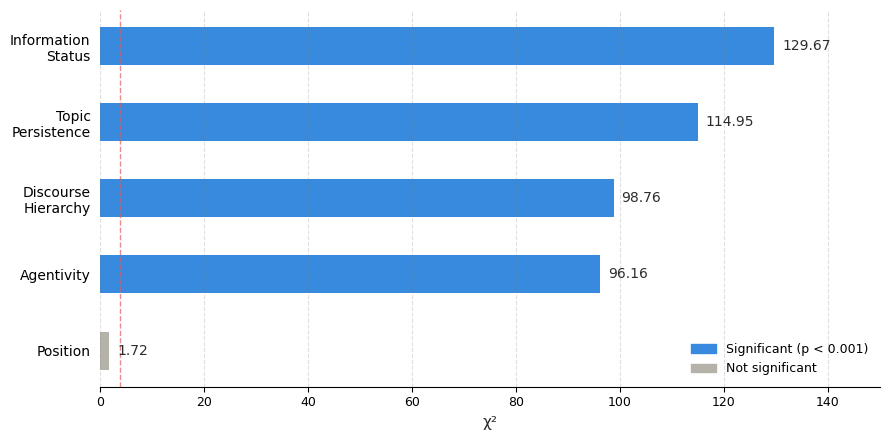

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

variables = ['Position', 'Agentivity', 'Discourse\nHierarchy', 'Topic\nPersistence', 'Information\nStatus']
values = [1.72, 96.16, 98.76, 114.95, 129.67]
colors = ['#B4B2A9', '#378ADD', '#378ADD', '#378ADD', '#378ADD']

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')

bars = ax.barh(variables, values, color=colors, edgecolor='none', height=0.5)

for bar, val in zip(bars, values):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', ha='left', fontsize=10, color='#2C2C2A')

ax.axvline(x=3.84, color='#E05C5C', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('χ²', fontsize=11, color='#2C2C2A')
ax.set_xlim(0, 150)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.25, color='gray')
ax.tick_params(axis='y', labelsize=10, left=False)
ax.tick_params(axis='x', labelsize=9)

sig_patch = mpatches.Patch(color='#378ADD', label='Significant (p < 0.001)')
ns_patch = mpatches.Patch(color='#B4B2A9', label='Not significant')
ax.legend(handles=[sig_patch, ns_patch], loc='lower right', fontsize=9, framealpha=0)

plt.tight_layout()
plt.savefig('chisquare_plot.pdf', bbox_inches='tight', facecolor='white')

from google.colab import files
files.download('chisquare_plot.pdf')

Saving DATA SET DEFINITIVO.xlsx to DATA SET DEFINITIVO (1).xlsx


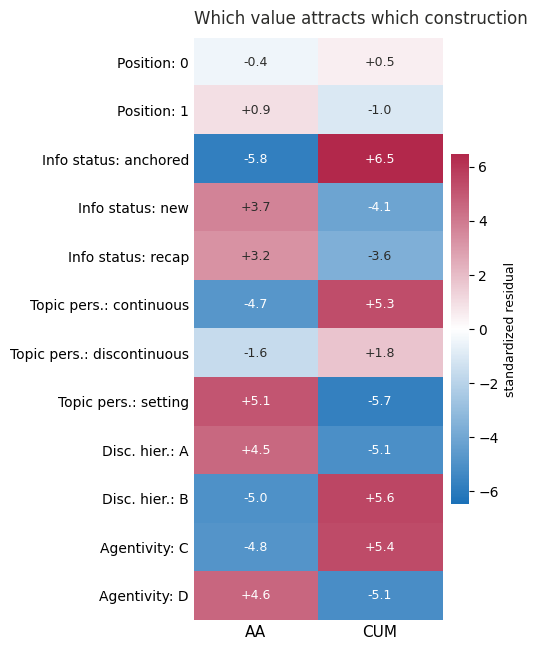

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# HEATMAP — associazione direzionale valori × costruzione
# (residui standardizzati di Pearson)
# ============================================================
import io
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- CARICA IL FILE (stesso del chi-square) ---
from google.colab import files
uploaded = files.upload()
df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))

df.columns = df.columns.str.strip()
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].str.strip()

# nome colonna -> etichetta breve
variabili = {
    'Position':            'Position',
    'information Status':  'Info status',
    'Topic persistence':   'Topic pers.',
    'Discourse Hierarchy': 'Disc. hier.',
    'Agentivity':          'Agentivity',
}

# ordine costruzioni (colonne)
constr_order = sorted(df['construction'].unique())   # es. ['AA', 'cum']

rows_labels, rows_data = [], []
for col, short in variabili.items():
    if col not in df.columns:
        print(f"ATTENZIONE: '{col}' non trovata. Colonne: {list(df.columns)}")
        continue
    ct = pd.crosstab(df[col], df['construction']).reindex(columns=constr_order, fill_value=0)
    _, _, _, expected = chi2_contingency(ct)
    resid = (ct.values - expected) / np.sqrt(expected)   # residui standardizzati
    for i, level in enumerate(ct.index):
        rows_labels.append(f"{short}: {level}")
        rows_data.append(resid[i])

M = np.array(rows_data)

# --- colormap brand: blu (evita) -> bianco -> magenta (attira) ---
cmap = LinearSegmentedColormap.from_list('brand', ['#1B71B8', '#FFFFFF', '#B2284B'])
vmax = np.nanmax(np.abs(M))

fig, ax = plt.subplots(figsize=(5.2, 0.45*len(rows_labels)+1.2))
fig.patch.set_facecolor('white')
im = ax.imshow(M, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(constr_order)))
ax.set_xticklabels(constr_order, fontsize=11)
ax.set_yticks(range(len(rows_labels)))
ax.set_yticklabels(rows_labels, fontsize=10)
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)

# annotazioni nelle celle
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = M[i, j]
        ax.text(j, i, f'{val:+.1f}', ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.6*vmax else '#2C2C2A')

cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.03)
cbar.set_label('standardized residual', fontsize=9)
cbar.outline.set_visible(False)
ax.set_title('Which value attracts which construction', fontsize=12,
             color='#2C2C2A', pad=10, loc='left')

plt.tight_layout()
plt.savefig('association_heatmap.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('association_heatmap.png', dpi=220, bbox_inches='tight', facecolor='white')
plt.show()
files.download('association_heatmap.pdf')